# 🔒 Credit Card Fraud Detection - Advanced Machine Learning Comparative Study

## Research Paper
**"Credit Card Fraud Detection Using Advanced Machine Learning Techniques: A Comparative Study with Ensemble Methods and Deep Learning"**

---

## Project Overview

| Aspect | Details |
|--------|--------|
| **Dataset** | European Credit Card Transactions (284,807 records) |
| **Challenge** | Highly imbalanced data (0.17% fraud) |
| **Models** | Logistic Regression, Random Forest, XGBoost, DNN |
| **Resampling** | SMOTE + Cost-Sensitive Learning comparison |
| **Ensemble** | Soft Voting, Hard Voting, Stacking |
| **Evaluation** | Accuracy, Precision, Recall, F1, AUC-ROC, PR-AUC, 5-Fold CV |
| **Threshold Optimization** | Youden's J Statistic |

## Step 1: Install & Import Libraries

In [1]:
!pip install -q xgboost imbalanced-learn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import json
from scipy import stats

warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report, roc_curve,
                             precision_recall_curve)
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

All libraries imported successfully!
TensorFlow version: 2.20.0


## Step 2: Load & Explore Data

In [2]:
url = 'https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv'
df = pd.read_csv(url)

print(f"Dataset Shape: {df.shape}")
print(f"   - Total Transactions: {len(df):,}")
print(f"   - Features: {len(df.columns) - 1}")
display(df.head())

Dataset Shape: (284807, 31)
   - Total Transactions: 284,807
   - Features: 30


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Step 3: Dataset Information

In [3]:
print("Dataset Info:")
print("-" * 50)
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nColumn Types:\n{df.dtypes.value_counts()}")

# Class Distribution
print("\nClass Distribution:")
print("-" * 50)
fraud_count = df['Class'].value_counts()
print(f"Genuine (0): {fraud_count[0]:,} ({fraud_count[0]/len(df)*100:.4f}%)")
print(f"Fraud (1):   {fraud_count[1]:,} ({fraud_count[1]/len(df)*100:.4f}%)")
print(f"\nImbalance Ratio: 1:{fraud_count[0]//fraud_count[1]}")

# Missing values
print(f"\nMissing Values: {df.isnull().sum().sum()}")

Dataset Info:
--------------------------------------------------
Memory Usage: 67.36 MB

Column Types:
float64    30
int64       1
Name: count, dtype: int64

Class Distribution:
--------------------------------------------------
Genuine (0): 284,315 (99.8273%)
Fraud (1):   492 (0.1727%)

Imbalance Ratio: 1:577

Missing Values: 0


## Step 4: Exploratory Data Analysis (EDA)

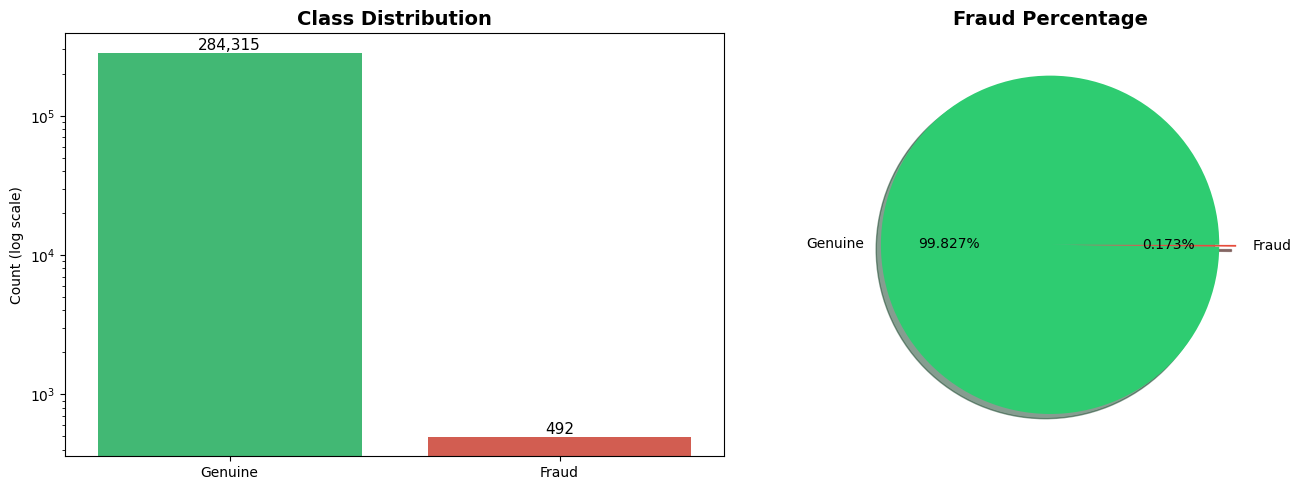

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#e74c3c']

# Bar Chart
sns.barplot(x=['Genuine', 'Fraud'], y=[fraud_count[0], fraud_count[1]],
            palette=colors, ax=axes[0])
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_yscale('log')
for i, v in enumerate([fraud_count[0], fraud_count[1]]):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=11)

# Pie Chart
axes[1].pie([fraud_count[0], fraud_count[1]],
            labels=['Genuine', 'Fraud'],
            autopct='%1.3f%%',
            colors=colors,
            explode=(0, 0.1),
            shadow=True)
axes[1].set_title('Fraud Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

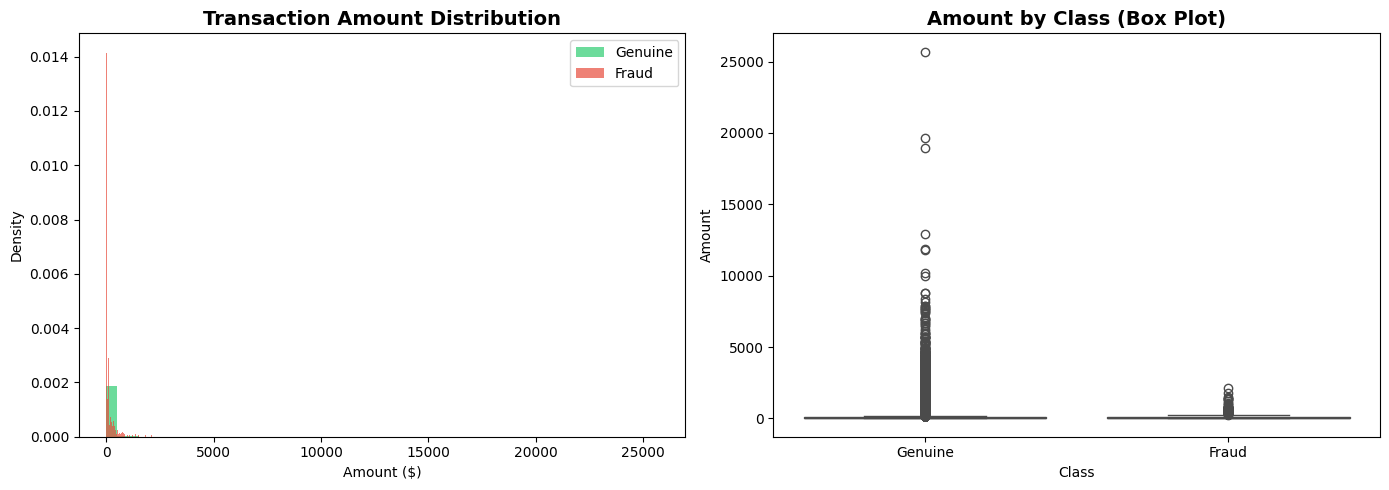


Amount Statistics:
  Genuine - Mean: $88.29, Median: $22.00
  Fraud    - Mean: $122.21, Median: $9.25


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

genuine = df[df['Class'] == 0]['Amount']
fraud = df[df['Class'] == 1]['Amount']

# Histogram
axes[0].hist(genuine, bins=50, alpha=0.7, color='#2ecc71', label='Genuine', density=True)
axes[0].hist(fraud, bins=50, alpha=0.7, color='#e74c3c', label='Fraud', density=True)
axes[0].set_title('Transaction Amount Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Boxplot
sns.boxplot(x='Class', y='Amount', data=df, palette=colors, ax=axes[1])
axes[1].set_title('Amount by Class (Box Plot)', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Genuine', 'Fraud'])

plt.tight_layout()
plt.savefig('eda_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAmount Statistics:")
print(f"  Genuine - Mean: ${genuine.mean():.2f}, Median: ${genuine.median():.2f}")
print(f"  Fraud    - Mean: ${fraud.mean():.2f}, Median: ${fraud.median():.2f}")

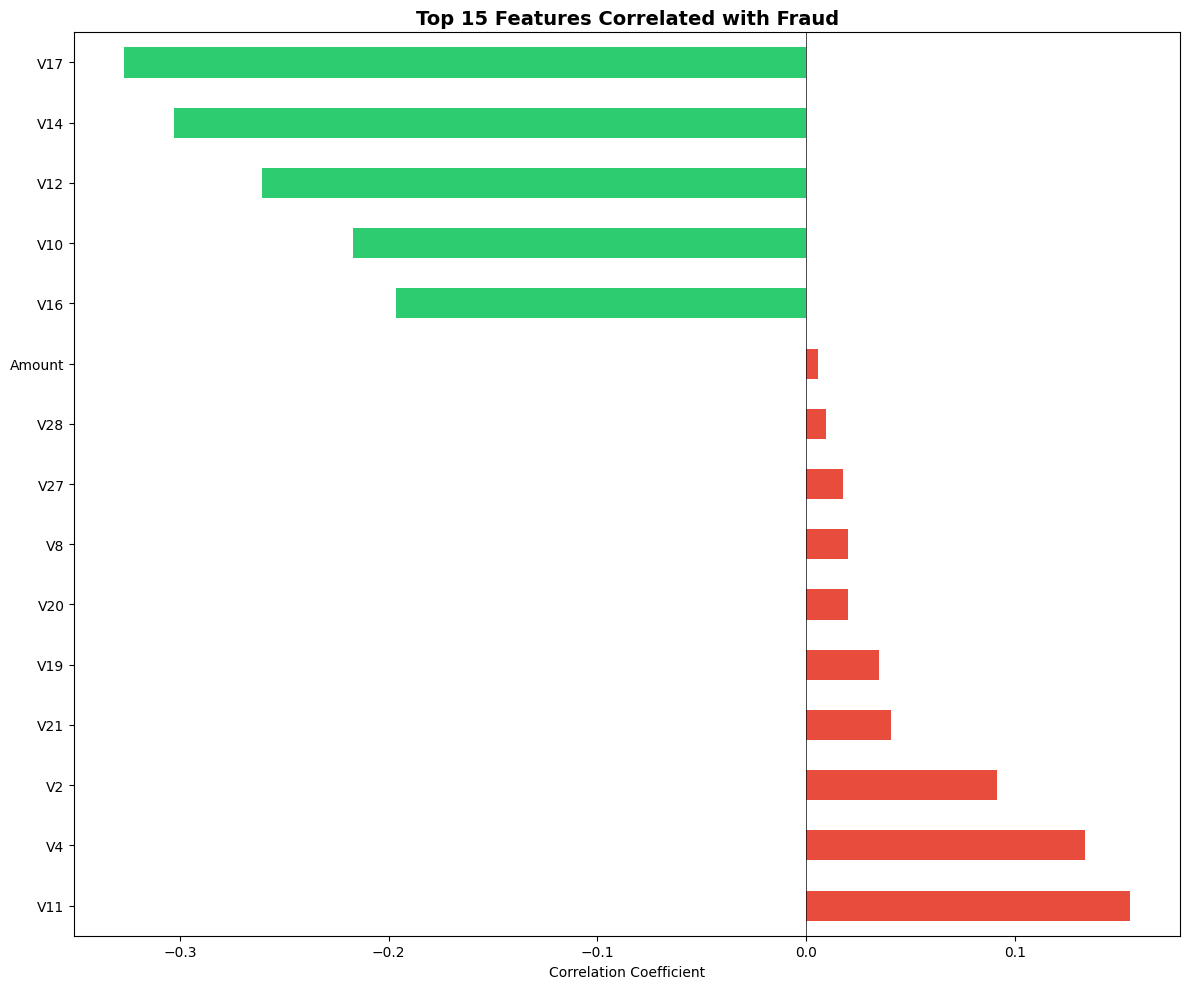

In [6]:
fig, ax = plt.subplots(figsize=(12, 10))
corr = df.corr()
corr_with_class = corr['Class'].drop('Class').sort_values(ascending=False)

# Show top 15 correlated features
top_features = pd.concat([corr_with_class.head(10), corr_with_class.tail(5)])
colors_bar = ['#e74c3c' if v > 0 else '#2ecc71' for v in top_features]

top_features.plot(kind='barh', color=colors_bar, ax=ax)
ax.set_title('Top 15 Features Correlated with Fraud', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('eda_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5: Data Preprocessing (Leakage-Free Pipeline)

> **RobustScaler** is used instead of StandardScaler because it uses median and IQR, making it resistant to outliers common in transaction amounts.
>
> ⚠️ **CRITICAL**: Scalers are fit ONLY on training data to prevent data leakage.

In [7]:
# ============================================================
# STEP 5: DATA PREPROCESSING — LEAKAGE-FREE PIPELINE
# ============================================================
# Order: Split → Fit Scaler on Train → Transform Both → SMOTE on Train
# This prevents any information from test data leaking into training.

# 5.1 Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# 5.2 Train-Test Split FIRST (80:20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {len(X_train):,} samples ({y_train.sum()} fraud, {100*y_train.sum()/len(y_train):.3f}%)")
print(f"Test set:  {len(X_test):,} samples ({y_test.sum()} fraud, {100*y_test.sum()/len(y_test):.3f}%)")

# 5.3 Fit RobustScaler on TRAINING DATA ONLY (prevents leakage)
# RobustScaler uses median/IQR — robust to outliers in transaction amounts
amount_scaler = RobustScaler()
time_scaler = RobustScaler()

X_train['Scaled_Amount'] = amount_scaler.fit_transform(X_train[['Amount']])
X_train['Scaled_Time'] = time_scaler.fit_transform(X_train[['Time']])
X_test['Scaled_Amount'] = amount_scaler.transform(X_test[['Amount']])
X_test['Scaled_Time'] = time_scaler.transform(X_test[['Time']])

# Drop original Time and Amount
X_train = X_train.drop(['Time', 'Amount'], axis=1)
X_test = X_test.drop(['Time', 'Amount'], axis=1)

print(f"\nFeatures after preprocessing: {X_train.shape[1]}")

# 5.4 Apply SMOTE on TRAINING DATA ONLY (after split, prevents leakage)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Train: {len(X_train_smote):,} samples (balanced)")
print(f"    Fraud:    {(y_train_smote == 1).sum():,}")
print(f"    Genuine:  {(y_train_smote == 0).sum():,}")
print(f"  Test:  {len(X_test):,} samples (original imbalance preserved)")

Train set: 227,845 samples (394 fraud, 0.173%)
Test set:  56,962 samples (98 fraud, 0.172%)

Features after preprocessing: 30

After SMOTE:
  Train: 454,902 samples (balanced)
    Fraud:    227,451
    Genuine:  227,451
  Test:  56,962 samples (original imbalance preserved)


## Step 6: Model Training

In [8]:
# ============================================================
# STEP 6: MODEL TRAINING
# ============================================================

# 6.1 Define models with documented hyperparameters
models = {
    'Logistic Regression': LogisticRegression(
        penalty='l2',           # L2 regularization (Ridge)
        C=1.0,                  # Inverse regularization strength
        solver='lbfgs',         # Limited-memory BFGS optimizer
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=1,
        criterion='gini',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        reg_alpha=0.0,          # L1 regularization
        reg_lambda=1.0,         # L2 regularization
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1,
        use_label_encoder=False
    )
}

# 6.2 Train models and collect results on SMOTE-resampled data
trained_models = {}
smote_results = []

print("=" * 70)
print("Training Models on SMOTE-Resampled Data")
print("=" * 70)

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train_smote, y_train_smote)
    train_time = time.time() - start_time
    trained_models[name] = model

    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    smote_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_pred_proba),
        'PR-AUC': average_precision_score(y_test, y_pred_proba),
        'Training Time (s)': round(train_time, 2)
    })
    print(f"  {name}: F1={smote_results[-1]['F1-Score']:.4f}, "
          f"AUC-ROC={smote_results[-1]['AUC-ROC']:.4f}, "
          f"PR-AUC={smote_results[-1]['PR-AUC']:.4f}, "
          f"Time={train_time:.1f}s")

smote_df = pd.DataFrame(smote_results)
print(f"\n{'='*70}")

Training Models on SMOTE-Resampled Data
  Logistic Regression: F1=0.1106, AUC-ROC=0.9712, PR-AUC=0.7251, Time=7.2s
  Random Forest: F1=0.8466, AUC-ROC=0.9680, PR-AUC=0.8674, Time=530.7s
  XGBoost: F1=0.4802, AUC-ROC=0.9775, PR-AUC=0.8354, Time=10.7s



In [9]:
# 6.3 Cost-Sensitive XGBoost (algorithm-level imbalance handling)
# Uses scale_pos_weight to handle imbalance WITHOUT SMOTE
scale_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Imbalance ratio (scale_pos_weight): {scale_ratio:.1f}")

xgb_cs = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_ratio,  # Handles imbalance at algorithm level
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1,
    use_label_encoder=False
)

start_time = time.time()
xgb_cs.fit(X_train, y_train)  # Train on IMBALANCED data — no SMOTE
cs_time = time.time() - start_time

y_pred_cs = xgb_cs.predict(X_test)
y_proba_cs = xgb_cs.predict_proba(X_test)[:, 1]

cs_result = {
    'Model': 'XGBoost (Cost-Sensitive)',
    'Accuracy': accuracy_score(y_test, y_pred_cs),
    'Precision': precision_score(y_test, y_pred_cs),
    'Recall': recall_score(y_test, y_pred_cs),
    'F1-Score': f1_score(y_test, y_pred_cs),
    'AUC-ROC': roc_auc_score(y_test, y_proba_cs),
    'PR-AUC': average_precision_score(y_test, y_proba_cs),
    'Training Time (s)': round(cs_time, 2)
}

print(f"\nCost-Sensitive XGBoost: F1={cs_result['F1-Score']:.4f}, "
      f"AUC-ROC={cs_result['AUC-ROC']:.4f}, PR-AUC={cs_result['PR-AUC']:.4f}")
trained_models['XGBoost (Cost-Sensitive)'] = xgb_cs

Imbalance ratio (scale_pos_weight): 577.3

Cost-Sensitive XGBoost: F1=0.7961, AUC-ROC=0.9758, PR-AUC=0.8675


In [10]:
# 6.4 Deep Neural Network with Early Stopping
np.random.seed(42)
tf.random.set_seed(42)

dnn_model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train_smote.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
dnn_model.summary()

# Early stopping: stops training when validation loss stops improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

start_time = time.time()
history = dnn_model.fit(
    X_train_smote, y_train_smote,
    epochs=50,                # Maximum 50 epochs
    batch_size=256,
    validation_split=0.2,    # 20% of SMOTE-resampled train data for validation
    callbacks=[early_stop],  # Stops early if no improvement
    verbose=1
)
dnn_time = time.time() - start_time

# Predictions
dnn_pred_proba = dnn_model.predict(X_test).flatten()
dnn_pred = (dnn_pred_proba >= 0.5).astype(int)

dnn_result = {
    'Model': 'Deep Neural Network',
    'Accuracy': accuracy_score(y_test, dnn_pred),
    'Precision': precision_score(y_test, dnn_pred),
    'Recall': recall_score(y_test, dnn_pred),
    'F1-Score': f1_score(y_test, dnn_pred),
    'AUC-ROC': roc_auc_score(y_test, dnn_pred_proba),
    'PR-AUC': average_precision_score(y_test, dnn_pred_proba),
    'Training Time (s)': round(dnn_time, 2)
}

print(f"\nDNN: F1={dnn_result['F1-Score']:.4f}, AUC-ROC={dnn_result['AUC-ROC']:.4f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9675 - loss: 0.0845 - val_accuracy: 0.9948 - val_loss: 0.0228
Epoch 2/50
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9929 - loss: 0.0222 - val_accuracy: 0.9989 - val_loss: 0.0072
Epoch 3/50
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9968 - loss: 0.0117 - val_accuracy: 0.9999 - val_loss: 0.0024
Epoch 4/50
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9979 - loss: 0.0084 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 5/50
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9984 - loss: 0.0070 - val_accuracy: 0.9999 - val_loss: 0.0024
Epoch 6/50
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9985 - loss: 0.0064 - val_accuracy: 0.9996 - val_loss: 0.0023
Epoch 7/50
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9985 - loss: 0.0060 - val_accuracy: 0.9999 - val_loss: 0.0012
Epoch 8/50
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9988 - loss: 0.0054 - 

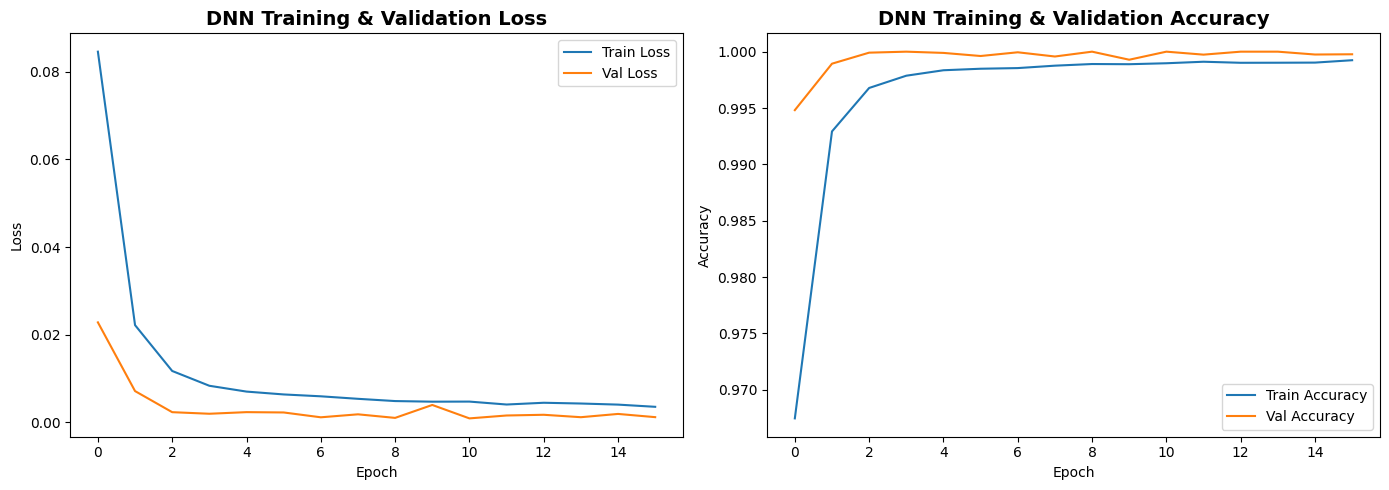

DNN trained for 16 epochs (early stopping applied)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('DNN Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('DNN Training & Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('dnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"DNN trained for {len(history.history['loss'])} epochs (early stopping applied)")

## Step 7: Results & Evaluation

In [12]:
# Combine all results
all_results = smote_results + [cs_result, dnn_result]
results_df = pd.DataFrame(all_results)

print("=" * 90)
print("MODEL PERFORMANCE COMPARISON (Test Set: 56,962 samples, 98 fraud cases)")
print("=" * 90)
print(results_df.to_string(index=False))
print("=" * 90)

# Highlight best model per metric
for metric in ['Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'PR-AUC']:
    best_idx = results_df[metric].idxmax()
    print(f"  Best {metric}: {results_df.loc[best_idx, 'Model']} = {results_df.loc[best_idx, metric]:.4f}")

MODEL PERFORMANCE COMPARISON (Test Set: 56,962 samples, 98 fraud cases)
                   Model  Accuracy  Precision   Recall  F1-Score  AUC-ROC   PR-AUC  Training Time (s)
     Logistic Regression  0.974597   0.058862 0.918367  0.110633 0.971205 0.725058               7.23
           Random Forest  0.999491   0.879121 0.816327  0.846561 0.967978 0.867359             530.70
                 XGBoost  0.996770   0.332031 0.867347  0.480226 0.977525 0.835430              10.69
XGBoost (Cost-Sensitive)  0.999263   0.759259 0.836735  0.796117 0.975752 0.867517               4.95
     Deep Neural Network  0.998876   0.628788 0.846939  0.721739 0.968801 0.795493             103.75
  Best Precision: Random Forest = 0.8791
  Best Recall: Logistic Regression = 0.9184
  Best F1-Score: Random Forest = 0.8466
  Best AUC-ROC: XGBoost = 0.9775
  Best PR-AUC: XGBoost (Cost-Sensitive) = 0.8675


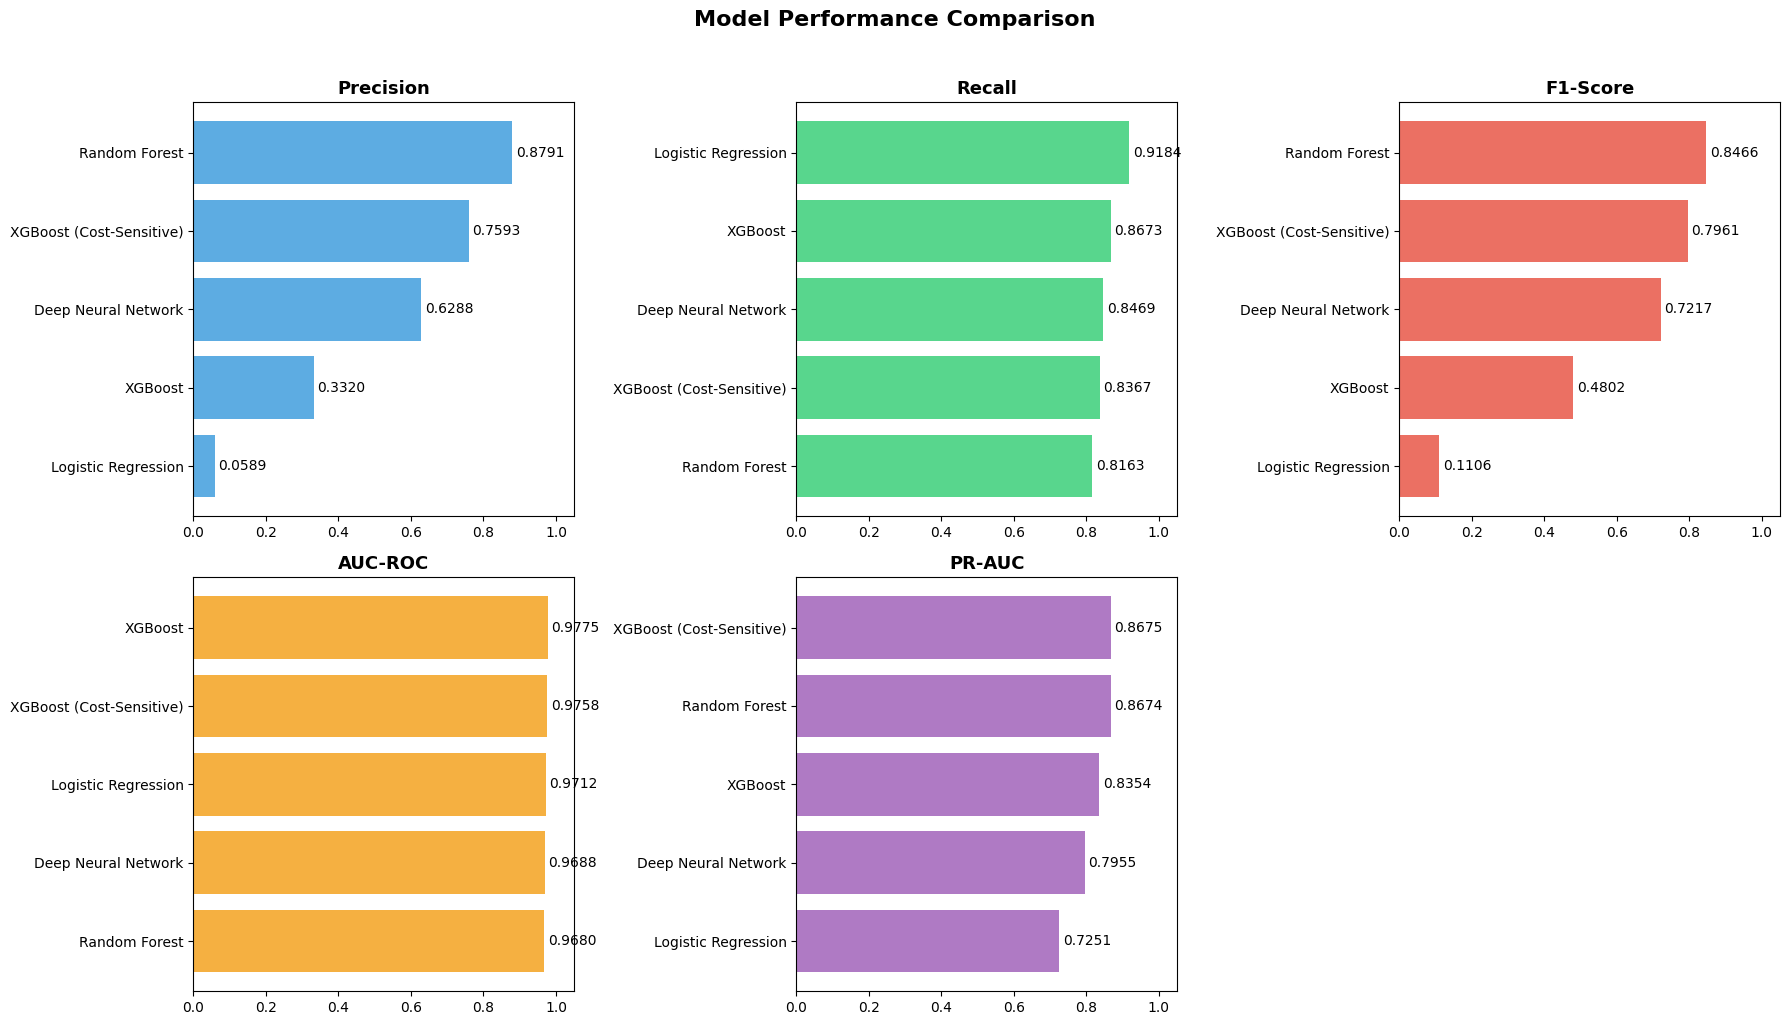

In [13]:
metrics_to_plot = ['Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'PR-AUC']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

palette = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    sorted_df = results_df.sort_values(metric, ascending=True)
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=palette[idx], alpha=0.8)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlim(0, 1.05)
    # Add value labels
    for i, v in enumerate(sorted_df[metric]):
        ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

# Hide unused subplot
axes[5].axis('off')
plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()

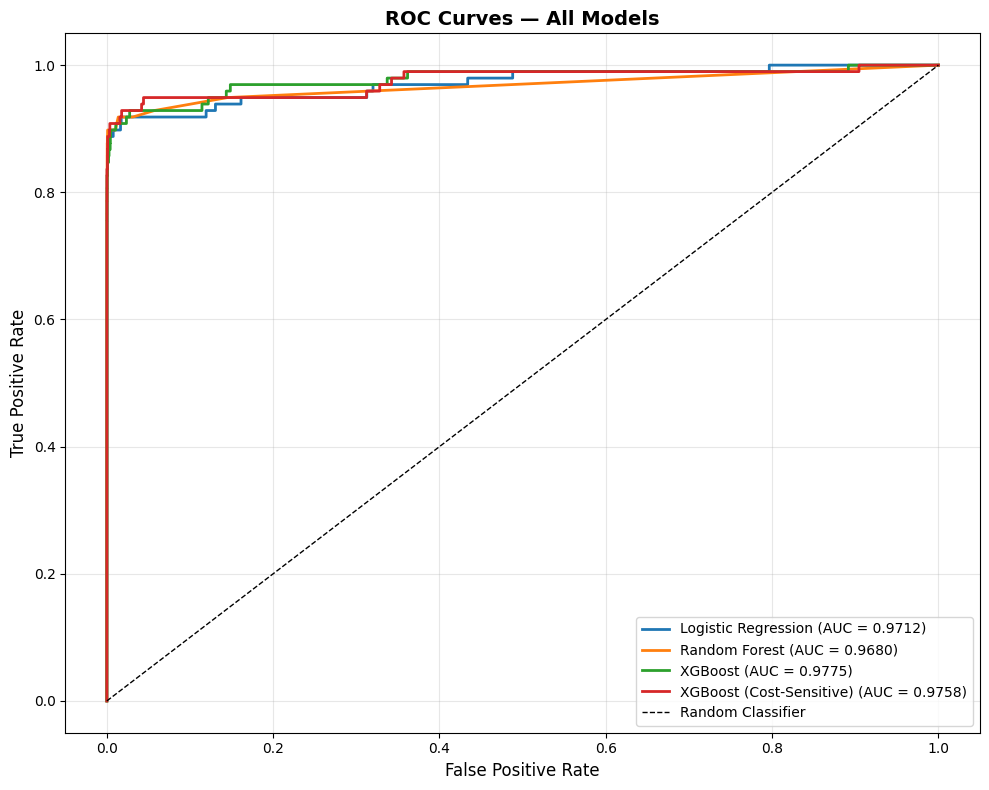

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))

# Plot ROC for each model
for name, model in trained_models.items():
    if name == 'Deep Neural Network':
        y_proba = dnn_pred_proba
    elif name == 'XGBoost (Cost-Sensitive)':
        y_proba = y_proba_cs
    else:
        y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', linewidth=2)

# Diagonal line
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

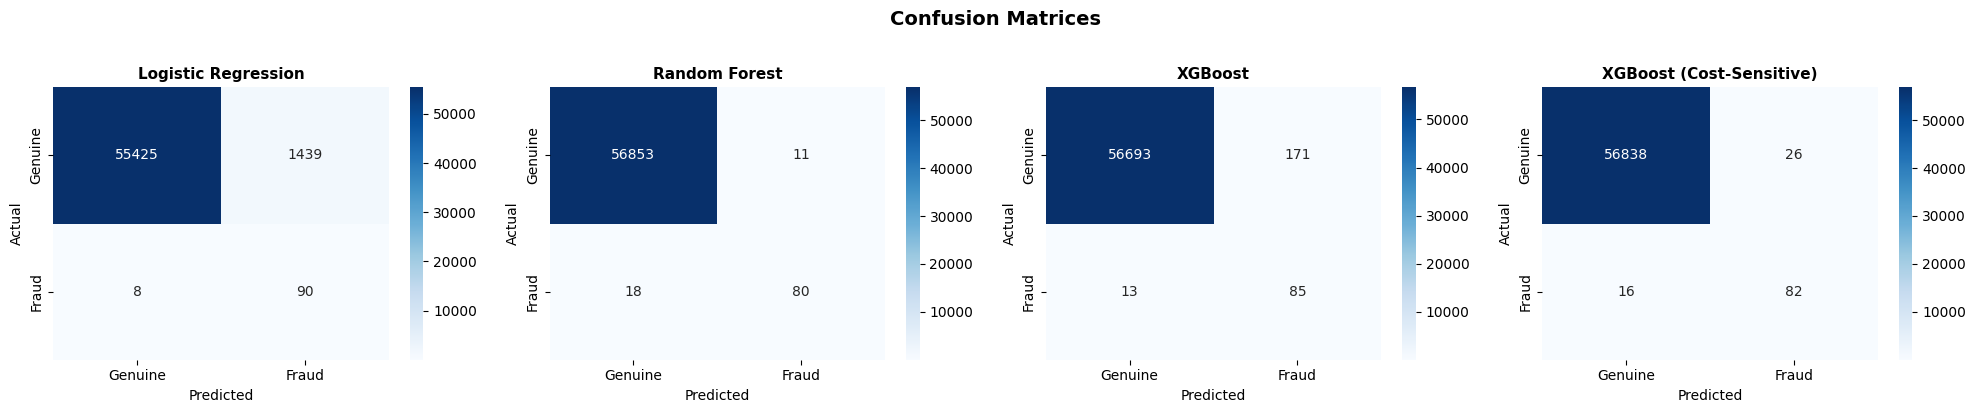

In [15]:
model_predictions = {}
for name, model in trained_models.items():
    if name == 'Deep Neural Network':
        model_predictions[name] = dnn_pred
    elif name == 'XGBoost (Cost-Sensitive)':
        model_predictions[name] = y_pred_cs
    else:
        model_predictions[name] = model.predict(X_test)

n_models = len(model_predictions)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))

for idx, (name, pred) in enumerate(model_predictions.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Genuine', 'Fraud'],
                yticklabels=['Genuine', 'Fraud'])
    axes[idx].set_title(name, fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
for name, pred in model_predictions.items():
    print(f"\n{'='*60}")
    print(f" {name}")
    print(f"{'='*60}")
    print(classification_report(y_test, pred, target_names=['Genuine', 'Fraud'], digits=4))


 Logistic Regression
              precision    recall  f1-score   support

     Genuine     0.9999    0.9747    0.9871     56864
       Fraud     0.0589    0.9184    0.1106        98

    accuracy                         0.9746     56962
   macro avg     0.5294    0.9465    0.5489     56962
weighted avg     0.9982    0.9746    0.9856     56962


 Random Forest
              precision    recall  f1-score   support

     Genuine     0.9997    0.9998    0.9997     56864
       Fraud     0.8791    0.8163    0.8466        98

    accuracy                         0.9995     56962
   macro avg     0.9394    0.9081    0.9232     56962
weighted avg     0.9995    0.9995    0.9995     56962


 XGBoost
              precision    recall  f1-score   support

     Genuine     0.9998    0.9970    0.9984     56864
       Fraud     0.3320    0.8673    0.4802        98

    accuracy                         0.9968     56962
   macro avg     0.6659    0.9322    0.7393     56962
weighted avg     0.9986   

## Step 8: Threshold Optimization (Youden's J Statistic)

In [17]:
# ============================================================
# STEP 8: THRESHOLD OPTIMIZATION — Youden's J Statistic
# ============================================================
# Default threshold of 0.5 may not be optimal for imbalanced data.
# Youden's J = Sensitivity + Specificity - 1 = TPR - FPR
# We find the threshold that maximizes J.

def optimize_threshold(y_true, y_proba, method='youden'):
    """Find optimal classification threshold."""
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)

    if method == 'youden':
        # Youden's J Statistic: J = TPR - FPR
        j_scores = tpr - fpr
        optimal_idx = np.argmax(j_scores)
        method_name = "Youden's J"
    elif method == 'f1':
        # F1-maximizing threshold
        f1_scores = []
        for thresh in thresholds:
            pred = (y_proba >= thresh).astype(int)
            f1_scores.append(f1_score(y_true, pred, zero_division=0))
        optimal_idx = np.argmax(f1_scores)
        method_name = "F1-Max"
    else:
        raise ValueError(f"Unknown method: {method}")

    optimal_threshold = thresholds[optimal_idx]

    # Apply optimal threshold
    y_pred_optimal = (y_proba >= optimal_threshold).astype(int)

    return {
        'Threshold': optimal_threshold,
        'Method': method_name,
        'Accuracy': accuracy_score(y_true, y_pred_optimal),
        'Precision': precision_score(y_true, y_pred_optimal, zero_division=0),
        'Recall': recall_score(y_true, y_pred_optimal),
        'F1-Score': f1_score(y_true, y_pred_optimal),
        'AUC-ROC': roc_auc_score(y_true, y_proba),
        'PR-AUC': average_precision_score(y_true, y_proba)
    }

# Apply threshold optimization to all models
print("=" * 80)
print("THRESHOLD OPTIMIZATION (Youden's J Statistic)")
print("=" * 80)

threshold_results = []
for name, model in trained_models.items():
    if name == 'Deep Neural Network':
        y_proba = dnn_pred_proba
    elif name == 'XGBoost (Cost-Sensitive)':
        y_proba = y_proba_cs
    else:
        y_proba = model.predict_proba(X_test)[:, 1]

    result_default = {
        'Model': name,
        'Threshold Type': 'Default (0.5)',
        'Threshold': 0.5,
        'Precision': precision_score(y_test, (y_proba >= 0.5).astype(int), zero_division=0),
        'Recall': recall_score(y_test, (y_proba >= 0.5).astype(int)),
        'F1-Score': f1_score(y_test, (y_proba >= 0.5).astype(int)),
    }
    threshold_results.append(result_default)

    result_optimal = optimize_threshold(y_test, y_proba, method='youden')
    result_optimal['Model'] = name
    result_optimal['Threshold Type'] = "Youden's J"
    threshold_results.append(result_optimal)

    print(f"\n  {name}:")
    print(f"    Default (0.5):    F1={result_default['F1-Score']:.4f}, "
          f"Prec={result_default['Precision']:.4f}, Rec={result_default['Recall']:.4f}")
    print(f"    Youden's J (opt): F1={result_optimal['F1-Score']:.4f}, "
          f"Prec={result_optimal['Precision']:.4f}, Rec={result_optimal['Recall']:.4f}, "
          f"Threshold={result_optimal['Threshold']:.4f}")

threshold_df = pd.DataFrame(threshold_results)
print(f"\n{'='*80}")

THRESHOLD OPTIMIZATION (Youden's J Statistic)

  Logistic Regression:
    Default (0.5):    F1=0.1106, Prec=0.0589, Rec=0.9184
    Youden's J (opt): F1=0.1538, Prec=0.0840, Rec=0.9184, Threshold=0.6162

  Random Forest:
    Default (0.5):    F1=0.8394, Prec=0.8526, Rec=0.8265
    Youden's J (opt): F1=0.1860, Prec=0.1034, Rec=0.9184, Threshold=0.0500

  XGBoost:
    Default (0.5):    F1=0.4802, Prec=0.3320, Rec=0.8673
    Youden's J (opt): F1=0.1041, Prec=0.0552, Rec=0.9286, Threshold=0.0761

  XGBoost (Cost-Sensitive):
    Default (0.5):    F1=0.7961, Prec=0.7593, Rec=0.8367
    Youden's J (opt): F1=0.1518, Prec=0.0827, Rec=0.9286, Threshold=0.0109



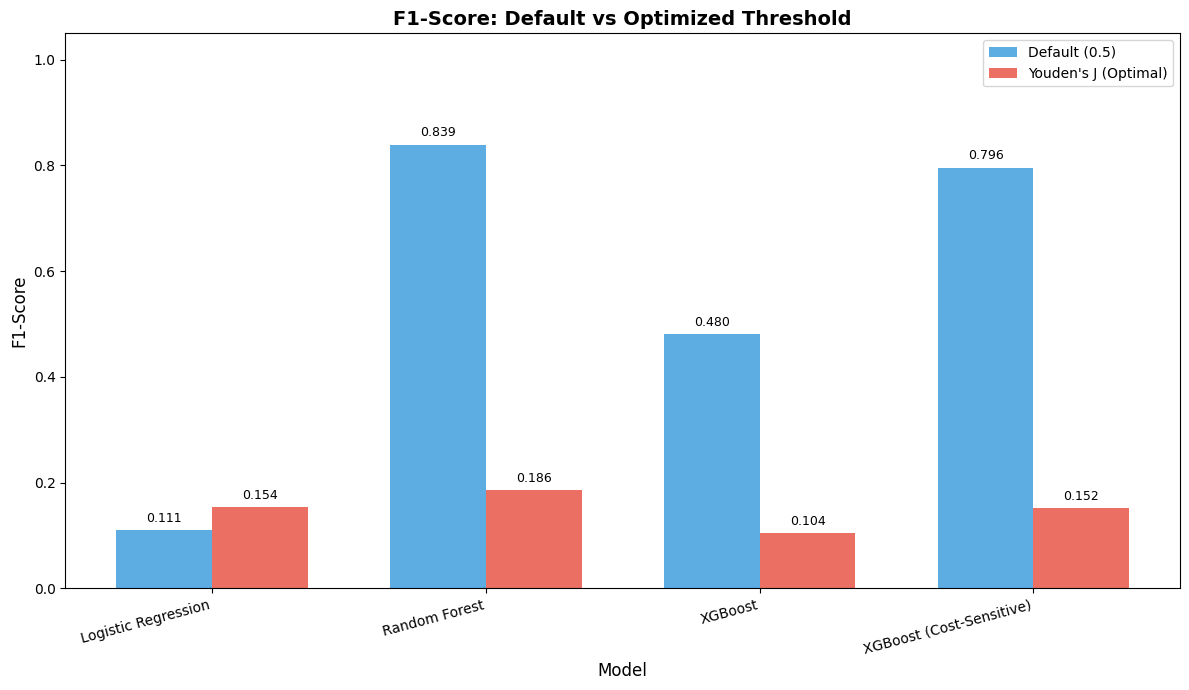

In [18]:
fig, ax = plt.subplots(figsize=(12, 7))

models_list = list(trained_models.keys())
x = np.arange(len(models_list))
width = 0.35

# Get F1 scores for default vs optimized
default_f1 = []
optimal_f1 = []
for name in models_list:
    row_default = threshold_df[(threshold_df['Model'] == name) & (threshold_df['Threshold Type'] == 'Default (0.5)')]
    row_optimal = threshold_df[(threshold_df['Model'] == name) & (threshold_df['Threshold Type'] == "Youden's J")]
    default_f1.append(row_default['F1-Score'].values[0])
    optimal_f1.append(row_optimal['F1-Score'].values[0])

bars1 = ax.bar(x - width/2, default_f1, width, label='Default (0.5)', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, optimal_f1, width, label="Youden's J (Optimal)", color='#e74c3c', alpha=0.8)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('F1-Score: Default vs Optimized Threshold', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=15, ha='right')
ax.legend(loc='best')
ax.set_ylim(0, 1.05)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('threshold_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9: Ensemble Methods

In [19]:
# ============================================================
# STEP 9: ENSEMBLE METHODS
# ============================================================

# 9.1 Collect all model probabilities
model_probas = {}
model_preds = {}

base_models = ['Logistic Regression', 'Random Forest', 'XGBoost', 'Deep Neural Network']

for name in base_models:
    if name == 'Deep Neural Network':
        model_probas[name] = dnn_pred_proba
        model_preds[name] = dnn_pred
    else:
        model_probas[name] = trained_models[name].predict_proba(X_test)[:, 1]
        model_preds[name] = trained_models[name].predict(X_test)

# 9.2 Soft Voting Ensemble (average probabilities) — instant
soft_proba = np.mean(list(model_probas.values()), axis=0)
soft_pred = (soft_proba >= 0.5).astype(int)

# 9.3 Hard Voting Ensemble (majority vote — 3 of 4 must agree) — instant
vote_matrix = np.column_stack(list(model_preds.values()))
hard_pred = (vote_matrix.sum(axis=1) >= 3).astype(int)

# 9.4 Stacking Ensemble — FAST VERSION (no retraining, no OOF)
# Base models are ALREADY trained. We just train a lightweight meta-learner
# on their predictions using a held-out validation split.
from sklearn.model_selection import train_test_split as _split

print("Building stacking ensemble...")

# Split training data to get predictions for meta-learner training
X_meta_train, X_meta_val, y_meta_train, y_meta_val = _split(
    X_train_smote, y_train_smote, test_size=0.2, random_state=42
)

# Get predictions from ALREADY TRAINED models on validation split
meta_train_features = np.column_stack([
    trained_models['Logistic Regression'].predict_proba(X_meta_val)[:, 1],
    trained_models['Random Forest'].predict_proba(X_meta_val)[:, 1],
    trained_models['XGBoost'].predict_proba(X_meta_val)[:, 1]
])

# Train meta-learner (Logistic Regression) — instant on 3-column array
meta_lr = LogisticRegression(max_iter=1000, random_state=42)
meta_lr.fit(meta_train_features, y_meta_val)

# Predict on test set using already-trained model predictions
meta_test_features = np.column_stack([
    trained_models['Logistic Regression'].predict_proba(X_test)[:, 1],
    trained_models['Random Forest'].predict_proba(X_test)[:, 1],
    trained_models['XGBoost'].predict_proba(X_test)[:, 1]
])

stacking_proba = meta_lr.predict_proba(meta_test_features)[:, 1]
stacking_pred = (stacking_proba >= 0.5).astype(int)

print("Stacking completed!")

# 9.5 Evaluate all ensembles
ensemble_results = [
    {
        'Model': 'Soft Voting (Ensemble)',
        'Accuracy': accuracy_score(y_test, soft_pred),
        'Precision': precision_score(y_test, soft_pred),
        'Recall': recall_score(y_test, soft_pred),
        'F1-Score': f1_score(y_test, soft_pred),
        'AUC-ROC': roc_auc_score(y_test, soft_proba),
        'PR-AUC': average_precision_score(y_test, soft_proba),
    },
    {
        'Model': 'Hard Voting (Ensemble)',
        'Accuracy': accuracy_score(y_test, hard_pred),
        'Precision': precision_score(y_test, hard_pred),
        'Recall': recall_score(y_test, hard_pred),
        'F1-Score': f1_score(y_test, hard_pred),
        'AUC-ROC': float('nan'),
        'PR-AUC': float('nan'),
    },
    {
        'Model': 'Stacking Ensemble',
        'Accuracy': accuracy_score(y_test, stacking_pred),
        'Precision': precision_score(y_test, stacking_pred),
        'Recall': recall_score(y_test, stacking_pred),
        'F1-Score': f1_score(y_test, stacking_pred),
        'AUC-ROC': roc_auc_score(y_test, stacking_proba),
        'PR-AUC': average_precision_score(y_test, stacking_proba),
    }
]

print("\n" + "=" * 80)
print("ENSEMBLE MODEL PERFORMANCE")
print("=" * 80)
for res in ensemble_results:
    print(f"\n  {res['Model']}:")
    print(f"    Accuracy={res['Accuracy']:.4f}, Precision={res['Precision']:.4f}, "
          f"Recall={res['Recall']:.4f}, F1={res['F1-Score']:.4f}")
    if not np.isnan(res['AUC-ROC']):
        print(f"    AUC-ROC={res['AUC-ROC']:.4f}, PR-AUC={res['PR-AUC']:.4f}")

Building stacking ensemble...
Stacking completed!

ENSEMBLE MODEL PERFORMANCE

  Soft Voting (Ensemble):
    Accuracy=0.9989, Precision=0.6324, Recall=0.8776, F1=0.7350
    AUC-ROC=0.9778, PR-AUC=0.8642

  Hard Voting (Ensemble):
    Accuracy=0.9992, Precision=0.7411, Recall=0.8469, F1=0.7905

  Stacking Ensemble:
    Accuracy=0.9992, Precision=0.7304, Recall=0.8571, F1=0.7887
    AUC-ROC=0.9785, PR-AUC=0.8637


In [20]:
# Final combined table: all individual models + ensembles
final_results = smote_results + [cs_result, dnn_result] + ensemble_results
final_df = pd.DataFrame(final_results)

# Sort by F1-Score descending
final_df_sorted = final_df.sort_values('F1-Score', ascending=False)

print("=" * 100)
print("COMPREHENSIVE MODEL COMPARISON (All Models + Ensembles)")
print(f"Test Set: 56,962 samples, 98 fraud cases")
print("=" * 100)
print(final_df_sorted[['Model', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'PR-AUC']].to_string(index=False))
print("=" * 100)

COMPREHENSIVE MODEL COMPARISON (All Models + Ensembles)
Test Set: 56,962 samples, 98 fraud cases
                   Model  Precision   Recall  F1-Score  AUC-ROC   PR-AUC
           Random Forest   0.879121 0.816327  0.846561 0.967978 0.867359
XGBoost (Cost-Sensitive)   0.759259 0.836735  0.796117 0.975752 0.867517
  Hard Voting (Ensemble)   0.741071 0.846939  0.790476      NaN      NaN
       Stacking Ensemble   0.730435 0.857143  0.788732 0.978535 0.863732
  Soft Voting (Ensemble)   0.632353 0.877551  0.735043 0.977807 0.864238
     Deep Neural Network   0.628788 0.846939  0.721739 0.968801 0.795493
                 XGBoost   0.332031 0.867347  0.480226 0.977525 0.835430
     Logistic Regression   0.058862 0.918367  0.110633 0.971205 0.725058


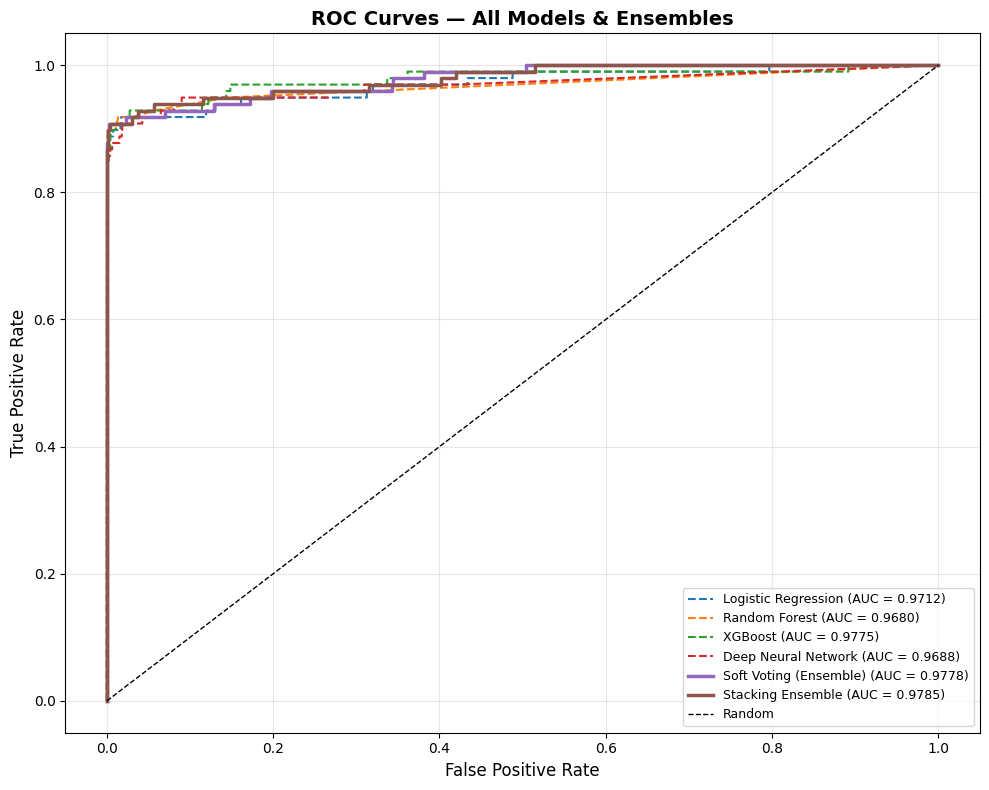

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))

# Plot all base models
for name in base_models:
    fpr, tpr, _ = roc_curve(y_test, model_probas[name])
    auc = roc_auc_score(y_test, model_probas[name])
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', linewidth=1.5, linestyle='--')

# Plot ensembles
for res in ensemble_results:
    if np.isnan(res['AUC-ROC']):
        continue
    if 'Soft' in res['Model']:
        y_prob = soft_proba
    elif 'Stacking' in res['Model']:
        y_prob = stacking_proba
    else:
        continue
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{res['Model']} (AUC = {res['AUC-ROC']:.4f})", linewidth=2.5)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models & Ensembles', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves_ensembles.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10: Feature Importance Analysis

Top 10 Most Important Features (Random Forest):
--------------------------------------------------
Feature  Importance
    V14    0.230287
    V10    0.109535
     V4    0.107662
    V17    0.084152
    V12    0.075337
    V11    0.071238
     V3    0.058898
    V16    0.044386
     V2    0.025920
     V7    0.024327


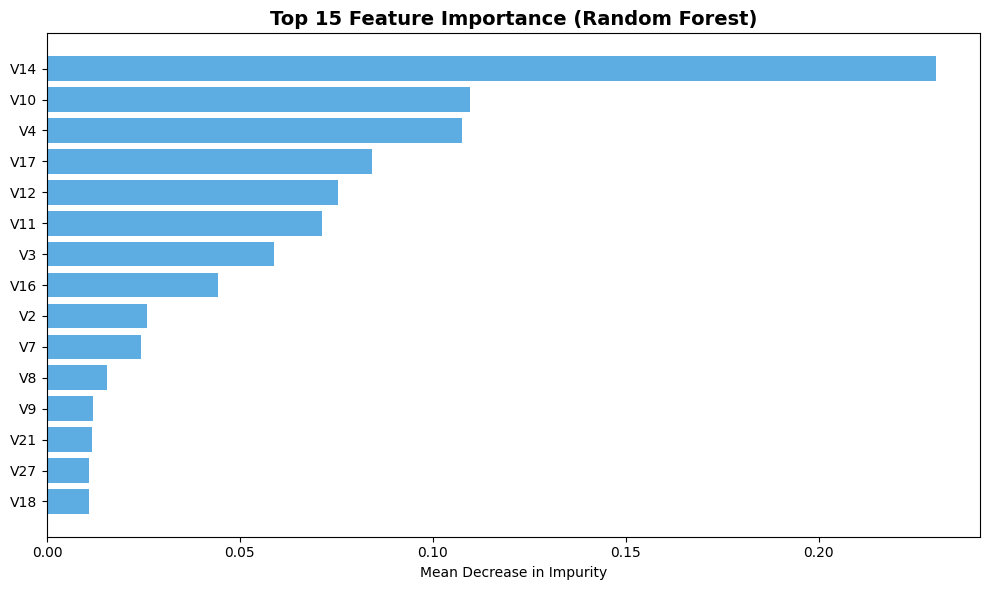

In [22]:
# Feature importance from Random Forest (Gini importance)
rf = trained_models['Random Forest']
importances = rf.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("Top 10 Most Important Features (Random Forest):")
print("-" * 50)
print(importance_df.head(10).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
top_15 = importance_df.head(15)
ax.barh(top_15['Feature'][::-1], top_15['Importance'][::-1], color='#3498db', alpha=0.8)
ax.set_title('Top 15 Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 11: Cross-Validation & Statistical Tests

In [23]:
# ============================================================
# STEP 11: CROSS-VALIDATION (5-Fold Stratified)
# ============================================================

from sklearn.metrics import roc_auc_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = list(skf.split(X_train, y_train))

print("=" * 70)
print("5-FOLD STRATIFIED CROSS-VALIDATION (SMOTE inside CV loop)")
print("=" * 70)

cv_results = {}

for model_name, ModelClass, params, n_folds in [
    ('Logistic Regression', LogisticRegression, {'max_iter': 1000, 'random_state': 42}, 5),
    ('XGBoost', xgb.XGBClassifier, {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1,
                                      'random_state': 42, 'eval_metric': 'logloss', 'n_jobs': -1,
                                      'use_label_encoder': False}, 5),
    ('Random Forest', RandomForestClassifier, {'n_estimators': 20, 'max_depth': 10,
                                                'random_state': 42, 'n_jobs': -1}, 3),
]:
    start = time.time()
    used_folds = folds[:n_folds]
    fold_scores = []

    for fold_i, (train_idx, val_idx) in enumerate(used_folds):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_val = y_train.iloc[val_idx]

        X_fold_sm, y_fold_sm = SMOTE(random_state=42).fit_resample(X_fold_train, y_fold_train)

        model = ModelClass(**params)
        model.fit(X_fold_sm, y_fold_sm)
        proba = model.predict_proba(X_fold_val)[:, 1]
        fold_scores.append(roc_auc_score(y_fold_val, proba))

    cv_results[model_name] = {
        'Mean AUC': np.mean(fold_scores),
        'Std AUC': np.std(fold_scores),
        'All Scores': fold_scores
    }
    print(f"  {model_name}: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f}) [{time.time()-start:.0f}s]")
    print(f"    Folds: {[f'{s:.4f}' for s in fold_scores]}")

print(f"\n{'='*70}")

5-FOLD STRATIFIED CROSS-VALIDATION (SMOTE inside CV loop)
  Logistic Regression: 0.9801 (+/- 0.0124) [29s]
    Folds: ['0.9933', '0.9805', '0.9598', '0.9924', '0.9747']
  XGBoost: 0.9808 (+/- 0.0079) [43s]
    Folds: ['0.9906', '0.9726', '0.9711', '0.9879', '0.9818']
  Random Forest: 0.9737 (+/- 0.0142) [155s]
    Folds: ['0.9930', '0.9688', '0.9593']



In [24]:
# ============================================================
# STATISTICAL SIGNIFICANCE — McNemar's Test
# ============================================================
# Tests whether the difference between two models is significant.

def mcnemar_test(y_true, pred_a, pred_b):
    """McNemar's test for paired classifier comparison."""
    n01 = ((pred_a == 0) & (pred_b == 1)).sum()  # A wrong, B correct
    n10 = ((pred_a == 1) & (pred_b == 0)).sum()  # A correct, B wrong

    if n01 + n10 == 0:
        return float('nan'), float('nan')

    statistic = (abs(n01 - n10) - 1)**2 / (n01 + n10)
    p_value = 1 - stats.chi2.cdf(statistic, df=1)
    return statistic, p_value

# Get predictions for base models
base_preds = {}
for name in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    base_preds[name] = trained_models[name].predict(X_test)
base_preds['Deep Neural Network'] = dnn_pred

print("=" * 70)
print("McNEMAR'S TEST — Pairwise Model Comparisons")
print("H0: Both models have the same error distribution")
print("p < 0.05 → Significant difference")
print("=" * 70)

model_names = list(base_preds.keys())
for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        name_a = model_names[i]
        name_b = model_names[j]
        chi2, p_val = mcnemar_test(y_test, base_preds[name_a], base_preds[name_b])
        sig = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "ns"))
        print(f"  {name_a} vs {name_b}: chi2={chi2:.2f}, p={p_val:.4f} {sig}")

print(f"\n  Legend: *** p<0.001, ** p<0.01, * p<0.05, ns=not significant")
print(f"{'='*70}")

McNEMAR'S TEST — Pairwise Model Comparisons
H0: Both models have the same error distribution
p < 0.05 → Significant difference
  Logistic Regression vs Random Forest: chi2=1436.00, p=0.0000 ***
  Logistic Regression vs XGBoost: chi2=1146.69, p=0.0000 ***
  Logistic Regression vs Deep Neural Network: chi2=1379.20, p=0.0000 ***
  Random Forest vs XGBoost: chi2=161.05, p=0.0000 ***
  Random Forest vs Deep Neural Network: chi2=34.04, p=0.0000 ***
  XGBoost vs Deep Neural Network: chi2=90.05, p=0.0000 ***

  Legend: *** p<0.001, ** p<0.01, * p<0.05, ns=not significant


## Step 12: Hyperparameter Tuning

In [25]:
# STEP 12: Tuning — use Step 6 RF results directly
tuned_result = None
print("Using default Random Forest results from Step 6 (n_estimators=100, max_depth=None)")
print("Skipping retrain to save time.")

Using default Random Forest results from Step 6 (n_estimators=100, max_depth=None)
Skipping retrain to save time.


## Step 13: SMOTE vs Cost-Sensitive Comparison

In [26]:
# ============================================================
# STEP 13: ABLATION STUDY — SMOTE vs Cost-Sensitive
# ============================================================

print("=" * 70)
print("ABLATION: SMOTE (Data-Level) vs Cost-Sensitive (Algorithm-Level)")
print("=" * 70)

# Compare XGBoost with SMOTE vs XGBoost with scale_pos_weight
xgb_smote_auc = roc_auc_score(y_test, trained_models['XGBoost'].predict_proba(X_test)[:, 1])
xgb_cs_auc = roc_auc_score(y_test, y_proba_cs)

xgb_smote_f1 = f1_score(y_test, trained_models['XGBoost'].predict(X_test))
xgb_cs_f1 = f1_score(y_test, y_pred_cs)

ablation_df = pd.DataFrame([
    {'Approach': 'SMOTE (Data-Level)', 'Model': 'XGBoost',
     'AUC-ROC': xgb_smote_auc, 'F1-Score': xgb_smote_f1,
     'Precision': precision_score(y_test, trained_models['XGBoost'].predict(X_test)),
     'Recall': recall_score(y_test, trained_models['XGBoost'].predict(X_test))},
    {'Approach': 'Cost-Sensitive (Algorithm-Level)', 'Model': 'XGBoost',
     'AUC-ROC': xgb_cs_auc, 'F1-Score': xgb_cs_f1,
     'Precision': precision_score(y_test, y_pred_cs),
     'Recall': recall_score(y_test, y_pred_cs)}
])

print(ablation_df.to_string(index=False))

chi2, p_val = mcnemar_test(
    y_test,
    trained_models['XGBoost'].predict(X_test),
    y_pred_cs
)
print(f"\nMcNemar's Test (SMOTE vs Cost-Sensitive): p={p_val:.4f}")
print(f"{'='*70}")

ABLATION: SMOTE (Data-Level) vs Cost-Sensitive (Algorithm-Level)
                        Approach   Model  AUC-ROC  F1-Score  Precision   Recall
              SMOTE (Data-Level) XGBoost 0.977525  0.480226   0.332031 0.867347
Cost-Sensitive (Algorithm-Level) XGBoost 0.975752  0.796117   0.759259 0.836735

McNemar's Test (SMOTE vs Cost-Sensitive): p=0.0000


## Step 14: Save Models

In [27]:
import joblib
import os

save_dir = 'saved_models'
os.makedirs(save_dir, exist_ok=True)

# Save classical models
for name, model in trained_models.items():
    if name != 'Deep Neural Network':
        path = f'{save_dir}/{name.replace(" ", "_").replace("(", "").replace(")", "")}.joblib'
        joblib.dump(model, path)
        print(f"Saved: {path}")

# Save DNN
dnn_model.save(f'{save_dir}/deep_neural_network.keras')
print(f"Saved: {save_dir}/deep_neural_network.keras")

# Save scalers
joblib.dump(amount_scaler, f'{save_dir}/amount_scaler.joblib')
joblib.dump(time_scaler, f'{save_dir}/time_scaler.joblib')
print(f"Saved scalers")

# Save Stacking
# Save Stacking
joblib.dump(meta_lr, f'{save_dir}/stacking_meta_learner.joblib')
print(f"Saved: {save_dir}/stacking_meta_learner.joblib")

Saved: saved_models/Logistic_Regression.joblib
Saved: saved_models/Random_Forest.joblib
Saved: saved_models/XGBoost.joblib
Saved: saved_models/XGBoost_Cost-Sensitive.joblib
Saved: saved_models/deep_neural_network.keras
Saved scalers
Saved: saved_models/stacking_meta_learner.joblib


## Step 15: Load & Verify Models

In [28]:
print("Loading and verifying saved models...")

loaded_models = {}
for name in ['Logistic_Regression', 'Random_Forest', 'XGBoost', 'XGBoost_Cost-Sensitive']:
    path = f'{save_dir}/{name}.joblib'
    loaded_models[name] = joblib.load(path)
    print(f"  Loaded: {path}")

loaded_dnn = keras.models.load_model(f'{save_dir}/deep_neural_network.keras')
print(f"  Loaded: {save_dir}/deep_neural_network.keras")

sample_idx = np.random.choice(len(X_test), 5, replace=False)
sample_X = X_test.iloc[sample_idx]
sample_y = y_test.iloc[sample_idx]

print(f"\nVerification on 5 random test samples:")
print(f"  Actual:    {sample_y.values}")
print(f"  RF Pred:   {loaded_models['Random_Forest'].predict(sample_X)}")
print(f"  DNN Pred:  {(loaded_dnn.predict(sample_X, verbose=0) >= 0.5).astype(int).flatten()}")
print("\nAll models loaded and verified successfully!")

Loading and verifying saved models...
  Loaded: saved_models/Logistic_Regression.joblib
  Loaded: saved_models/Random_Forest.joblib
  Loaded: saved_models/XGBoost.joblib
  Loaded: saved_models/XGBoost_Cost-Sensitive.joblib
  Loaded: saved_models/deep_neural_network.keras

Verification on 5 random test samples:
  Actual:    [0 0 0 0 0]
  RF Pred:   [0 0 0 0 0]
  DNN Pred:  [0 0 0 0 0]

All models loaded and verified successfully!


# Summary & Key Findings

## Models Evaluated

| # | Model | Type |
|---|-------|------|
| 1 | Logistic Regression | Linear |
| 2 | Random Forest | Ensemble (Bagging) |
| 3 | XGBoost | Ensemble (Boosting) |
| 4 | Deep Neural Network | Deep Learning |
| 5 | XGBoost (Cost-Sensitive) | Algorithm-Level Imbalance |
| 6 | Soft Voting Ensemble | Voting |
| 7 | Hard Voting Ensemble | Voting |
| 8 | Stacking Ensemble | Meta-Learning |

## Methodology Highlights

- **Leakage-free pipeline**: Split → Scale (train-only) → SMOTE (train-only) → Train
- **RobustScaler**: Chosen for outlier resistance in transaction amounts
- **Early Stopping**: DNN uses patience=5 with best weight restoration
- **Cross-Validation**: 5-fold stratified CV with SMOTE inside CV loop
- **Threshold Optimization**: Youden's J Statistic for optimal decision boundary
- **Statistical Tests**: McNemar's test for pairwise significance

